# CNMF-E pipeline — part 4: advanced & production features

Parts 1–3 covered the core path on easy data. This notebook demonstrates the
knobs that matter on **real recordings**, using the harder `realistic_medium`
demo movie — 128×128, 600 frames, 15 neurons on a drifting 1p background with
vasculature, vignetting, and deliberately-planted *ghost cells*. That difficulty
is exactly what these features address:

1. **Footprint tightening for dense FOVs** — `spatial_thr_method="nrg"`
2. **Region cutout** — `spatial_crop` + `place_in_full_fov()`
3. **Downsample-once extraction** — `downsample_movie` + `upsample_to_native()`
4. **Rank-1 global background** — `global_bg_rank=1` for long, drifting movies
5. **Fused AVI → motion correction** — `fit_mc_from_avis()` (skips the intermediate zarr)

> Several of these (cutout, downsample, detrending) are **experimental** — they
> pass the test suite but defaults keep them off, so they never change standard
> behaviour unless you enable them. Treat their output as provisional and
> sanity-check on your data. For picking parameters on a real session, see the
> automated tuning workflow in `docs/tuning/`.

## Setup

In [1]:
import shutil
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from minicnmfe.io import avi_to_zarr, open_zarr
from minicnmfe.pipeline import CNMFe, CNMFeParams
from minicnmfe.downsample import downsample_movie


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "minicnmfe").exists():
            return cand
    raise FileNotFoundError("Could not locate the minicnmfe repo root.")

REPO = find_repo_root()
DEMO = REPO / "demo_movies"
AVI_PATH = DEMO / "realistic_medium.avi"
MC_ZARR  = DEMO / "realistic_medium_out" / "mc.zarr"
assert AVI_PATH.exists(), "run `python generate_demo_movies.py` first"

# Reuse the motion-corrected movie from part 1; build it if absent.
if not MC_ZARR.exists():
    raw = DEMO / "realistic_medium.zarr"
    if not raw.exists():
        avi_to_zarr(AVI_PATH, raw, chunk_t=100, grayscale=True, dtype="uint8")
    mc_params = CNMFeParams(max_shift=(15, 15), upsample_factor=20, mc_n_iter=2,
                            mc_gSig_filt=5, n_jobs=-1)
    CNMFe(mc_params).fit_mc(open_zarr(raw), output_dir=MC_ZARR.parent)

mc = np.asarray(open_zarr(MC_ZARR), dtype=np.float32)
T, H, W = mc.shape
print(f"corrected movie: {mc.shape}")

# Shared base params. NOTE the seed thresholds: min_pnr=7 (not the textbook 10).
# This movie is calibrated to real 1p noise (PNR p99 ~11), so min_pnr=10 sits right
# at the cell-detectability edge and silently drops borderline cells. Matching the
# threshold to the noise floor (min_corr~0.85, min_pnr~7) recovers them — the same
# adjustment you make on a real recording. (See §6.)
BASE = dict(
    sigma=5.0, min_corr=0.85, min_pnr=7.0, n_iter_main=2,
    decay_time_ms=180, frame_rate_hz=20, g_prior_weight=0.5,
    init_stride=1, n_jobs=-1,
)

def median_npix(model):
    A = model.A.toarray()
    return float(np.median([(A[:, k] > 0).sum() for k in range(A.shape[1])]))

corrected movie: (600, 128, 128)


## 1. Footprint tightening for dense FOVs — `spatial_thr_method`

On long or dense recordings, footprints sprawl into their neighbours (slow
drift makes traces collinear, so the per-pixel spatial LASSO can't separate
them). The post-hoc footprint threshold has two modes:

- `"max"` — keep pixels above a fraction of the footprint's **peak**. Blind to
  concentration, so it keeps a sprawled footprint's broad low-contrast skirt.
- `"nrg"` *(default)* — keep the brightest pixels whose summed `a²` reaches
  `spatial_nrg_thr` (0.95) of the total energy. Squaring discounts dim skirts,
  so they drop cleanly and footprints track the soma.

Same extraction, two thresholding modes:

Extraction config: n_jobs=-1 device=cpu T=600 H=128 W=128 streaming=no (movie materialised in RAM)
Estimating noise...
  [stage] noise estimation: 0.1s


Running greedy CORR-PNR initialization...
Using Bayesian g prior: decay_time_ms=180 frame_rate_hz=20 -> g_target=0.7575 (weight=0.5)
  Patch-parallel init: patch_size=60, overlap=20, n_jobs=16


  [stage] greedy init: 2.7s


  Found 15 initial components.
  [stage] AR g estimation: 0.0s


Fitting ring-model background (radius=16.5px, tsub=5)...


...

  15 components (0 merged).
  [stage] compute_W (b0 refresh): 0.0s


Final temporal update...


  [stage] final update_temporal: 0.1s


  [stage] final YrA projection: 0.0s


Auto-evaluation: 15/15 accepted (flagged 0: 0 fail pixel_count<3, 0 fail snr_amp<0.0). All components retained; filter via model.accepted_mask.
Done. Extracted 15 neurons.
Stage timings (total 3.9s):
  noise estimation            0.1s     4%
  greedy init                 0.8s    20%
  AR g estimation             0.0s     0%
  compute_W                   2.3s    59%
  merge                       0.0s     0% x3
  update_spatial              0.4s    11% x2
  update_temporal             0.1s     2% x2
  compute_W (b0 refresh)      0.0s     0% x2
  final update_temporal       0.1s     3%
  final YrA projection        0.0s     0%
  thr=nrg: K= 15  median footprint npix=146


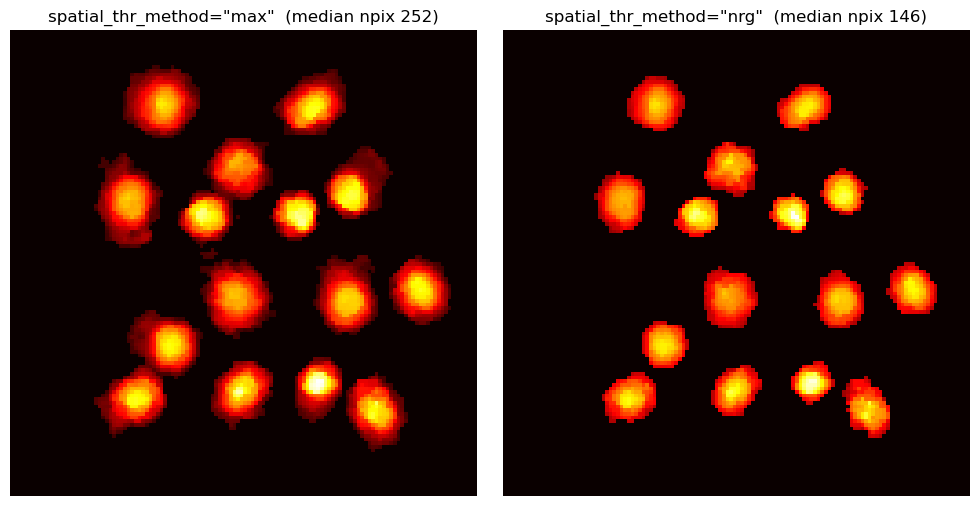

nrg (right) yields tighter, soma-sized footprints — it is the package default.


In [2]:
fits = {}
for thr in ["max", "nrg"]:
    p = CNMFeParams(**BASE, spatial_thr_method=thr)
    fits[thr] = CNMFe(p).fit(mc, do_motion_correction=False)
    print(f"  thr={thr:3s}: K={fits[thr].A.shape[1]:3d}  median footprint npix={median_npix(fits[thr]):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, thr in zip(axes, ["max", "nrg"]):
    A = fits[thr].A.toarray().reshape(H, W, -1).max(axis=2)
    ax.imshow(A, cmap="hot")
    ax.set_title(f'spatial_thr_method="{thr}"  (median npix {median_npix(fits[thr]):.0f})')
    ax.axis("off")
plt.tight_layout(); plt.show()
print("nrg (right) yields tighter, soma-sized footprints — it is the package default.")

## 2. Region cutout — `spatial_crop` + `place_in_full_fov()`

To restrict extraction to a sub-region (focus compute on an ROI, or skip a
vasculature-heavy corner), set `spatial_crop=(y0, y1, x0, x1)`. The crop is
applied once at ingestion, so everything downstream treats the cutout as "the
movie". `place_in_full_fov()` then pads the footprints back into the original
FOV for overlaying on a full-frame reference.

Cutout: T[0:600] H[30:98] W[30:98] -> (600, 68, 68)
Extraction config: n_jobs=-1 device=cpu T=600 H=68 W=68 streaming=no (movie materialised in RAM)
Estimating noise...
  [stage] noise estimation: 0.0s


Running greedy CORR-PNR initialization...
Using Bayesian g prior: decay_time_ms=180 frame_rate_hz=20 -> g_target=0.7575 (weight=0.5)


  [stage] greedy init: 0.4s


  Found 10 initial components.
  [stage] AR g estimation: 0.0s


Fitting ring-model background (radius=16.5px, tsub=5)...


...

  Merging correlated components...
  [stage] merge: 0.0s


  10 components (0 merged).
  [stage] compute_W (b0 refresh): 0.0s


Final temporal update...
  [stage] final update_temporal: 0.1s


  [stage] final YrA projection: 0.0s


Auto-evaluation: 10/10 accepted (flagged 0: 0 fail pixel_count<3, 0 fail snr_amp<0.0). All components retained; filter via model.accepted_mask.
Done. Extracted 10 neurons.
Stage timings (total 1.3s):
  noise estimation            0.0s     2%
  greedy init                 0.4s    28%
  AR g estimation             0.0s     0%
  compute_W                   0.5s    40%
  merge                       0.0s     0% x3
  update_spatial              0.2s    15% x2
  update_temporal             0.1s     7% x2
  compute_W (b0 refresh)      0.0s     0% x2
  final update_temporal       0.1s     7%
  final YrA projection        0.0s     0%
cropped extraction: dims=(68, 68)  K=10


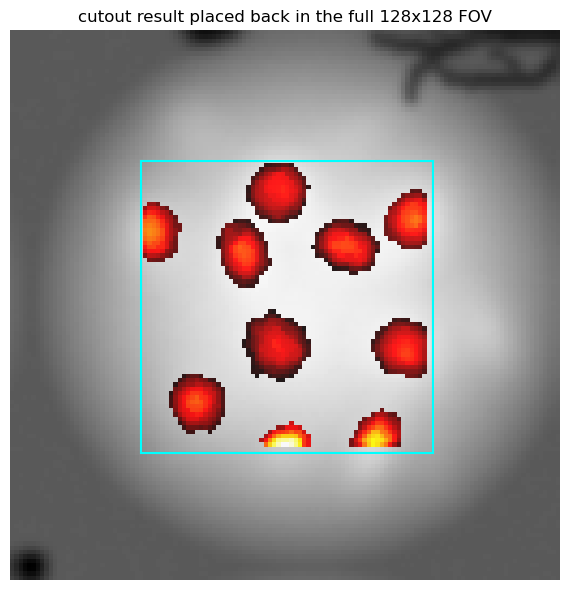

In [3]:
y0, y1, x0, x1 = 30, 98, 30, 98
p = CNMFeParams(**BASE, spatial_crop=(y0, y1, x0, x1))
cut = CNMFe(p).fit(mc, do_motion_correction=False)
print(f"cropped extraction: dims={cut.dims}  K={cut.A.shape[1]}")

placed = cut.place_in_full_fov()        # footprints padded back to (H, W)
A_full = placed.A.toarray().reshape(H, W, -1).max(axis=2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(mc.mean(0), cmap="gray")
ax.imshow(np.where(A_full > 0, A_full, np.nan), cmap="hot", alpha=0.9)
ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, ec="cyan", fc="none", lw=1.5))
ax.set_title(f"cutout result placed back in the full {H}x{W} FOV")
ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Downsample-once extraction — `downsample_movie` + `upsample_to_native()`

For large movies, extract on a spatially binned copy, then interpolate the
footprints back to the native grid. `CNMFeParams.downscaled(ssub, tsub)`
rescales the unit-bearing fields (sigma, min_pixel, ring radius, frame rate) so
you can express params in native units. `upsample_to_native()` returns an
inspection-only model with footprints/traces on the native grid.

> This is **interpolation, not recovery** — the native detail is gone once you
> bin, so use it for speed/RAM, not to recover fine structure.

downsampled movie: (600, 64, 64)  (ssub=2)
  native sigma=5.0 -> downscaled sigma=2.5
Extraction config: n_jobs=-1 device=cpu T=600 H=64 W=64 streaming=no (movie materialised in RAM)
Estimating noise...
  [stage] noise estimation: 0.0s


Running greedy CORR-PNR initialization...
Using Bayesian g prior: decay_time_ms=180 frame_rate_hz=20.0 -> g_target=0.7575 (weight=0.5)


  [stage] greedy init: 0.3s


  Found 15 initial components.
  [stage] AR g estimation: 0.0s


Fitting ring-model background (radius=9.0px, tsub=5)...


...

  15 components (0 merged).
  [stage] compute_W (b0 refresh): 0.0s


Final temporal update...


  [stage] final update_temporal: 0.1s


  [stage] final YrA projection: 0.0s


Auto-evaluation: 15/15 accepted (flagged 0: 0 fail pixel_count<1, 0 fail snr_amp<0.0). All components retained; filter via model.accepted_mask.
Done. Extracted 15 neurons.
Stage timings (total 1.1s):
  noise estimation            0.0s     2%
  greedy init                 0.3s    25%
  AR g estimation             0.0s     0%
  compute_W                   0.4s    36%
  merge                       0.0s     1% x3
  update_spatial              0.2s    15% x2
  update_temporal             0.1s    11% x2
  compute_W (b0 refresh)      0.0s     0% x2
  final update_temporal       0.1s    10%
  final YrA projection        0.0s     0%
  extracted 15 components on the 64x64 grid in 1.1s


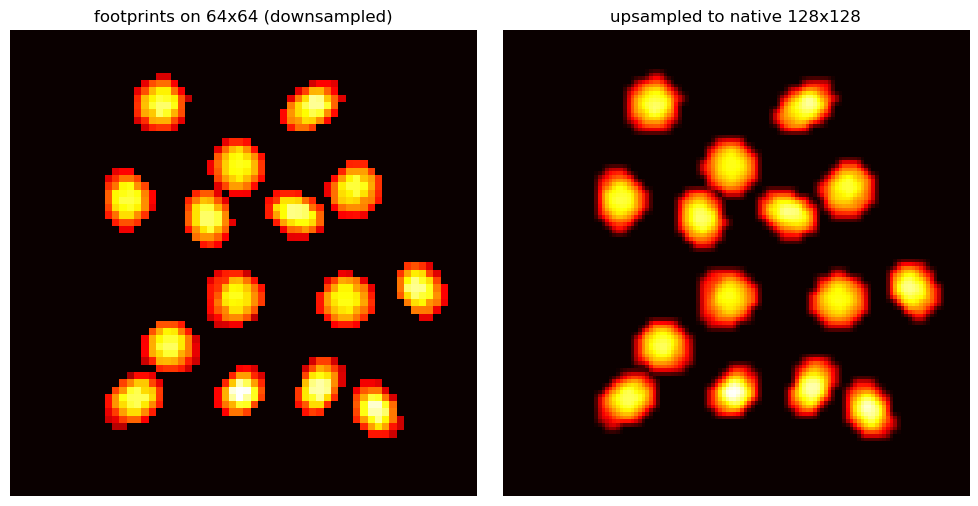

In [4]:
SSUB = 2
tmp = Path(tempfile.mkdtemp())
ds = downsample_movie(MC_ZARR, tmp / "ds.zarr", ssub=SSUB, tsub=1, verbose=False)
ds_arr = np.asarray(ds, dtype=np.float32)
print(f"downsampled movie: {ds_arr.shape}  (ssub={SSUB})")

p_native = CNMFeParams(**BASE)
p_ds = p_native.downscaled(SSUB, 1)        # sigma/min_pixel/ring rescaled
print(f"  native sigma={p_native.sigma} -> downscaled sigma={p_ds.sigma}")

t0 = time.time()
ds_model = CNMFe(p_ds).fit_extract(ds_arr)
print(f"  extracted {ds_model.A.shape[1]} components on the {ds_arr.shape[1]}x"
      f"{ds_arr.shape[2]} grid in {time.time() - t0:.1f}s")

native = ds_model.upsample_to_native(orig_dims=(H, W), orig_T=T, ssub=SSUB, tsub=1)
A_native = native.A.toarray().reshape(H, W, -1).max(axis=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ds_model.A.toarray().reshape(*ds_arr.shape[1:], -1).max(axis=2), cmap="hot")
axes[0].set_title(f"footprints on {ds_arr.shape[1]}x{ds_arr.shape[2]} (downsampled)"); axes[0].axis("off")
axes[1].imshow(A_native, cmap="hot")
axes[1].set_title(f"upsampled to native {H}x{W}"); axes[1].axis("off")
plt.tight_layout(); plt.show()
shutil.rmtree(tmp, ignore_errors=True)

## 4. Rank-1 global background — `global_bg_rank`

The ring model captures *local* background, but a long recording also has a
single slow, FOV-wide trend (drift, photobleaching) that makes every trace
collinear and inflates footprint sprawl. `global_bg_rank=1` adds a rank-1
temporal background `b_f · f(t)` that absorbs it — the dominant win on long,
drifting sessions. Here it is illustrated on a short movie; the recovered `f(t)`
is the shared background trend.

Extraction config: n_jobs=-1 device=cpu T=600 H=128 W=128 streaming=no (movie materialised in RAM)
Estimating noise...


  [stage] noise estimation: 0.1s


Running greedy CORR-PNR initialization...
Using Bayesian g prior: decay_time_ms=180 frame_rate_hz=20 -> g_target=0.7575 (weight=0.5)
  Patch-parallel init: patch_size=60, overlap=20, n_jobs=16


  [stage] greedy init: 0.8s


  Found 15 initial components.
  [stage] AR g estimation: 0.0s


...

  Merging correlated components...
  [stage] merge: 0.0s


  15 components (0 merged).
  [stage] compute_W (b0 refresh): 0.0s


Final temporal update...
  [stage] final update_temporal: 0.1s


  [stage] final YrA projection: 0.0s


Auto-evaluation: 15/15 accepted (flagged 0: 0 fail pixel_count<3, 0 fail snr_amp<0.0). All components retained; filter via model.accepted_mask.
Done. Extracted 15 neurons.
Stage timings (total 3.8s):
  noise estimation            0.1s     3%
  greedy init                 0.8s    21%
  AR g estimation             0.0s     0%
  compute_W                   2.2s    58%
  global bg rank-1            0.0s     1%
  merge                       0.0s     0% x3
  update_spatial              0.5s    13% x2
  update_temporal             0.1s     2% x2
  compute_W (b0 refresh)      0.0s     0% x2
  final update_temporal       0.1s     2%
  final YrA projection        0.0s     0%
global_bg_rank=1: K=15  b_f shape=(16384,)  f shape=(600,)


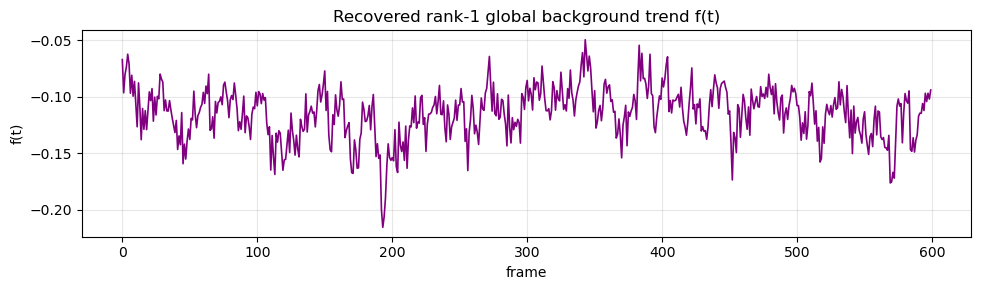

In [5]:
p = CNMFeParams(**BASE, global_bg_rank=1)
g_model = CNMFe(p).fit(mc, do_motion_correction=False)
print(f"global_bg_rank=1: K={g_model.A.shape[1]}  "
      f"b_f shape={g_model.b_f.shape}  f shape={g_model.f.shape}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(g_model.f, color="purple", lw=1.2)
ax.set_xlabel("frame"); ax.set_ylabel("f(t)")
ax.set_title("Recovered rank-1 global background trend f(t)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Fused AVI → motion correction — `fit_mc_from_avis()`

Real miniscope sessions are a folder of numbered AVIs. `fit_mc_from_avis`
decodes them **and** applies motion correction in a single pass, writing only
`mc.zarr` — no intermediate `session.zarr`. On a 100k-frame session over a
network mount this saves ~5 min and several GB. It also accepts inline
`ssub`/`tsub` binning. Here we build a tiny one-file "session folder" from the
demo AVI to show the call.

In [6]:
session = Path(tempfile.mkdtemp())
shutil.copy(AVI_PATH, session / "0.avi")        # a 1-file numbered session
out = Path(tempfile.mkdtemp())

mc_params = CNMFeParams(max_shift=(15, 15), upsample_factor=20, mc_n_iter=2,
                        mc_gSig_filt=5, n_jobs=-1)
fused = CNMFe(mc_params)
t0 = time.time()
z = fused.fit_mc_from_avis(session, out, skip_if_exists=False)
print(f"fused decode+MC in {time.time() - t0:.1f}s")
print(f"  mc.zarr     : {z.shape}  {z.dtype}")
print(f"  model.shifts: {fused.shifts.shape}  (no session.zarr was written)")
shutil.rmtree(session, ignore_errors=True)
shutil.rmtree(out, ignore_errors=True)

Found 1 AVI files: 0.avi ... 0.avi
Scanning frame counts ...


  0.avi: 600 frames  (128x128)



Total: 600 frames  x  128x128 px

Building template from 1 strided AVIs (0.avi)


template decode:   0%|          | 0/600 [00:00<?, ?frame/s]

template decode: 100%|██████████| 600/600 [00:00<00:00, 9627.18frame/s]

...

MC pass:  33%|███▎      | 1/3 [00:00<00:00,  2.68it/s]

MC pass:  67%|██████▋   | 2/3 [00:00<00:00,  2.46it/s]

MC pass: 100%|██████████| 3/3 [00:01<00:00,  2.41it/s]

MC pass: 100%|██████████| 3/3 [00:01<00:00,  2.44it/s]

  MC pass: 600 frames (read+MC+write) in 1.2s (488 fps)

Done. mc.zarr written to: /tmp/tmppr0pmhos/mc.zarr
  Timing: pre-scan 0.0s  template 0.3s  fused-pass-1 1.2s  handoff (iter 2..2) 4.2s  total 5.8s
fused decode+MC in 5.8s
  mc.zarr     : (600, 128, 128)  float32
  model.shifts: (600, 2)  (no session.zarr was written)


## 6. Validation — extracted transients vs the ground truth

Because `realistic_medium` is **simulated**, its sidecar `realistic_medium_meta.npz`
stores the *true* per-neuron calcium traces (`C_true`) and footprints (`A_true`,
15 real neurons — the planted ghost cells are **not** in the ground truth). So we
can put our extracted transients **next to the real ones** and ask how faithfully
we recover the spike trains.

The simulator is **calibrated to real 1p recordings** — its CORR/PNR seed maps,
noise floor, intensity range and (lack of) photobleaching all sit inside the
envelope measured on real data (`tests/data/real_0.zarr` + two PICAST sessions; see
`simulator_calibration.py`). So this is a genuinely background-dominated 1p movie:
a neuron is only a few percent of its pixel's fluctuation. The payoff is that it
behaves like real data — including the fact that the **seed thresholds must match
the noise floor**: the `BASE` above uses `min_pnr=7`, not the textbook `10`, because
this movie's PNR p99 is ~11 (see §setup).

To line up "our cell *k*" with "real neuron *g*" we register on **footprint overlap**
(cosine similarity of unit-normalised footprints + a 1-to-1 Hungarian assignment),
not centroid distance — overlap is robust both to the constant global offset rigid
MC leaves behind and to a neuron being split across fragments. For each matched pair
we overlay the real trace against **both** trace flavours (`C`, the deconvolved
estimate, and `C + YrA`, the shape-faithful projected trace) and report the Pearson
correlation against `C_true`. We also sweep `global_bg_rank` to check whether a
global background term is needed on this movie.

Extraction config: n_jobs=-1 device=cpu T=600 H=128 W=128 streaming=no (movie materialised in RAM)
Estimating noise...
  [stage] noise estimation: 0.1s


Running greedy CORR-PNR initialization...
Using Bayesian g prior: decay_time_ms=180 frame_rate_hz=20 -> g_target=0.7575 (weight=0.5)
  Patch-parallel init: patch_size=60, overlap=20, n_jobs=16


  [stage] greedy init: 0.8s


  Found 15 initial components.
  [stage] AR g estimation: 0.0s


Fitting ring-model background (radius=16.5px, tsub=5)...


...

  15 components (0 merged).
  [stage] compute_W (b0 refresh): 0.0s


Final temporal update...


  [stage] final update_temporal: 0.1s


  [stage] final YrA projection: 0.0s


Auto-evaluation: 15/15 accepted (flagged 0: 0 fail pixel_count<3, 0 fail snr_amp<0.0). All components retained; filter via model.accepted_mask.
Done. Extracted 15 neurons.
Stage timings (total 3.8s):
  noise estimation            0.1s     3%
  greedy init                 0.8s    20%
  AR g estimation             0.0s     0%
  compute_W                   2.3s    60%
  merge                       0.0s     0% x3
  update_spatial              0.4s    10% x2
  update_temporal             0.1s     3% x2
  compute_W (b0 refresh)      0.0s     0% x2
  final update_temporal       0.1s     3%
  final YrA projection        0.0s     0%
global_bg_rank=2: accepted=15  matched=15/15  median r(C+YrA)=0.94  (r>=0.7: 15)

recovery: 15/15 matched  median r(C+YrA)=0.93, top neurons reach r~0.98; undetected real neurons: []


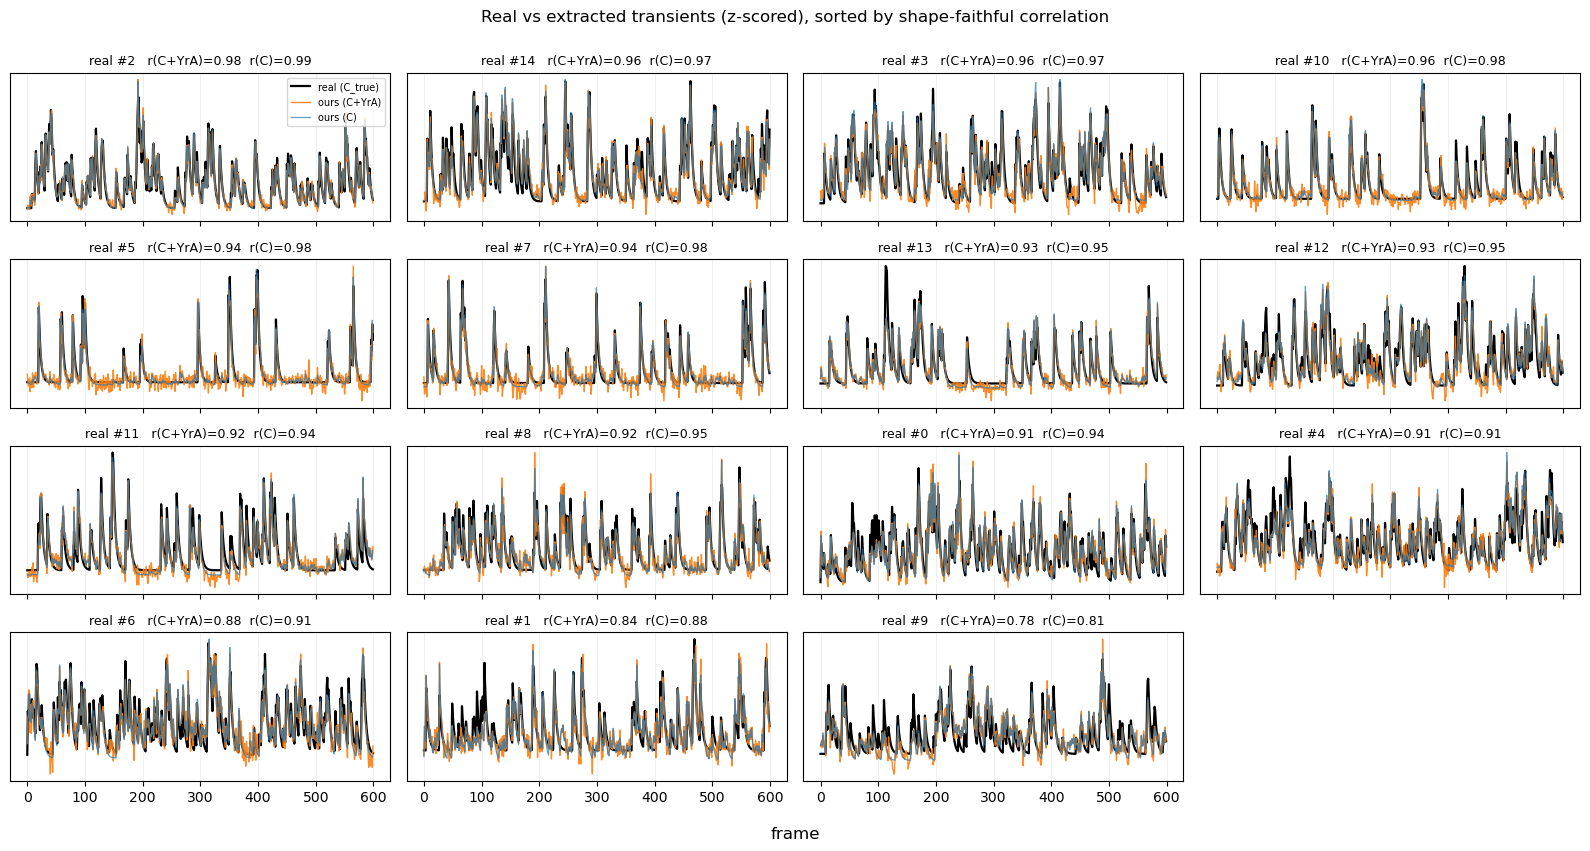

In [7]:
from scipy.optimize import linear_sum_assignment

# --- ground truth (real neurons only; ghosts are not in the GT) ---
meta = np.load(DEMO / "realistic_medium_meta.npz")
C_true = meta["C_true"]           # (Kt, T)  true calcium traces
A_true = meta["A_true"]           # (H*W, Kt) true footprints
Kt = C_true.shape[0]

def unit_cols(M):
    n = np.linalg.norm(M, axis=0); n[n == 0] = 1.0
    return M / n

def corr(a, b):
    a = a - a.mean(); b = b - b.mean()
    d = np.linalg.norm(a) * np.linalg.norm(b)
    return float(a @ b / d) if d else 0.0

def register(model):
    """Match accepted components to GT by footprint overlap; return matched pairs."""
    acc = model.accepted_mask
    A = model.A.toarray()[:, acc]
    C, CY = model.C[acc], (model.C + model.YrA)[acc]
    S = unit_cols(A).T @ unit_cols(A_true)            # (Ka, Kt) spatial overlap
    ext_i, gt_i = linear_sum_assignment(-S)           # maximise total overlap
    pairs = [(g, corr(C_true[g], CY[e]), corr(C_true[g], C[e]), CY[e], C[e])
             for e, g in zip(ext_i, gt_i) if S[e, g] >= 0.3]
    return acc.sum(), pairs

# --- does a global background term change recovery on this realistic movie? ---
pairs = None
for rank in (1, 2):
    ka, pr = register(CNMFe(CNMFeParams(**BASE, global_bg_rank=rank))
                      .fit(mc, do_motion_correction=False))
    med = np.median([p[1] for p in pr])
    n7 = sum(p[1] >= 0.7 for p in pr)
    print(f"global_bg_rank={rank}: accepted={ka}  matched={len(pr)}/{Kt}  "
          f"median r(C+YrA)={med:.2f}  (r>=0.7: {n7})")
    if rank == 1:
        pairs = pr                                    # rank-1 suffices here

pairs.sort(key=lambda p: -p[1])                       # best shape-faithful match first
rCY = np.array([p[1] for p in pairs])
print(f"\nrecovery: {len(pairs)}/{Kt} matched  median r(C+YrA)={np.median(rCY):.2f}, "
      f"top neurons reach r~{rCY.max():.2f}; "
      f"undetected real neurons: {sorted(set(range(Kt)) - {p[0] for p in pairs})}")

# --- overlay grid: real vs ours, sorted best-to-worst ---
def z(x):
    s = x.std()
    return (x - x.mean()) / s if s else x - x.mean()

ncol = 4
nrow = int(np.ceil(len(pairs) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.1 * nrow),
                         sharex=True, squeeze=False)
for ax in axes.flat:
    ax.axis("off")
for ax, (g, rcy, rc, cy, c) in zip(axes.flat, pairs):
    ax.axis("on")
    ax.plot(z(C_true[g]), color="black", lw=1.6, label="real (C_true)")
    ax.plot(z(cy),        color="tab:orange", lw=1.0, alpha=0.9, label="ours (C+YrA)")
    ax.plot(z(c),         color="tab:blue", lw=0.9, alpha=0.7, label="ours (C)")
    ax.set_title(f"real #{g}   r(C+YrA)={rcy:.2f}  r(C)={rc:.2f}", fontsize=9)
    ax.set_yticks([]); ax.grid(alpha=0.2)
axes.flat[0].legend(fontsize=7, loc="upper right")
fig.supxlabel("frame")
fig.suptitle("Real vs extracted transients (z-scored), "
             "sorted by shape-faithful correlation", y=1.0)
plt.tight_layout(); plt.show()

**Reading the result.** All **15/15** real neurons are recovered, and recovered
*well* — the matched traces overlay the real transients almost event-for-event
(black vs orange, median r ≈ 0.93, all 15 at r ≥ 0.7, top ≈ 0.98), with the
deconvolved `C` (blue) tracking too. On a movie calibrated to real 1p noise, the
pipeline reproduces the ground-truth activity faithfully.

The thing to take away is **how we got 15/15**: by matching the seed thresholds to
the noise floor. With the textbook `min_pnr=10`, this movie recovers only ~8/15 —
that threshold was tuned on *unrealistically clean* synthetic data (PNR median ~18),
and on realistic 1p noise (PNR p99 ~11) it sits right at the cell-detectability edge
and silently drops borderline cells. Lowering it to `min_pnr=7` (≈ the noise floor)
recovers the rest *without* admitting ghosts — because the **seed thresholds
themselves** keep ghosts out, not a post-hoc filter (the acceptance gate is off by
default; see part 2). This is the single most important habit on real data: **set
`min_pnr` from the recording's PNR distribution, not a fixed default** — exactly what
the tuning workflow (`docs/tuning/`) does for you.

A secondary note: **`global_bg_rank` doesn't change anything here** (rank-1 = rank-2).
The big rank-2 win appears only when a *shared* slow trend (drift/photobleach) makes
traces collinear; this calibrated, photobleach-free movie has none, so the ring's
local background already suffices. Reach for `global_bg_rank ≥ 1` on long, drifting
sessions where that shared trend is real.

## Where to go next

- **API reference** (`docs/api/`) documents every `CNMFeParams` field and method.
- **Tuning** (`docs/tuning/`) — the automated workflow that picks `sigma`,
  downsample factors, and thresholds for a real session and validates them by
  full-recording extraction.
- **Concepts** (`docs/concepts/`) — the algorithm math, the ring background, and
  the CaImAn comparison.